Shape: (119040, 31)

Columns:
 Index(['STA', 'Date', 'Precip', 'WindGustSpd', 'MaxTemp', 'MinTemp',
       'MeanTemp', 'Snowfall', 'PoorWeather', 'YR', 'MO', 'DA', 'PRCP', 'DR',
       'SPD', 'MAX', 'MIN', 'MEA', 'SNF', 'SND', 'FT', 'FB', 'FTI', 'ITH',
       'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE'],
      dtype='object')
Numeric columns:
 Index(['STA', 'WindGustSpd', 'MaxTemp', 'MinTemp', 'MeanTemp', 'YR', 'MO',
       'DA', 'DR', 'SPD', 'MAX', 'MIN', 'MEA', 'SND', 'PGT'],
      dtype='object')
                 STA  WindGustSpd        MaxTemp        MinTemp  \
count  119040.000000   532.000000  119040.000000  119040.000000   
mean    29659.435795    37.774534      27.045111      17.789511   
std     20953.209402    10.297808       8.717817       8.334572   
min     10001.000000    18.520000     -33.333333     -38.333333   
25%     11801.000000    29.632000      25.555556      15.000000   
50%     22508.000000    37.040000      29.444444      21.111111   
75%     33501.0

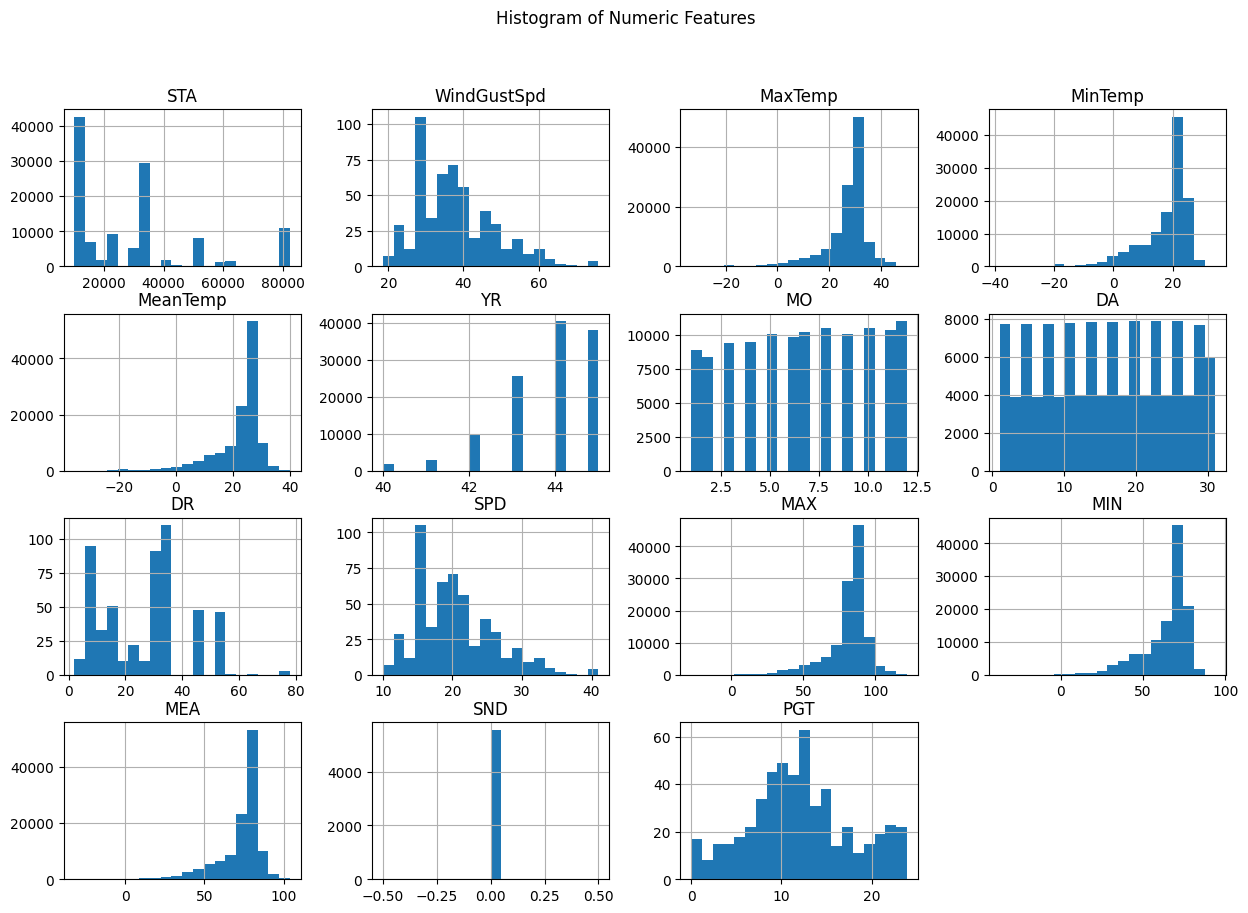

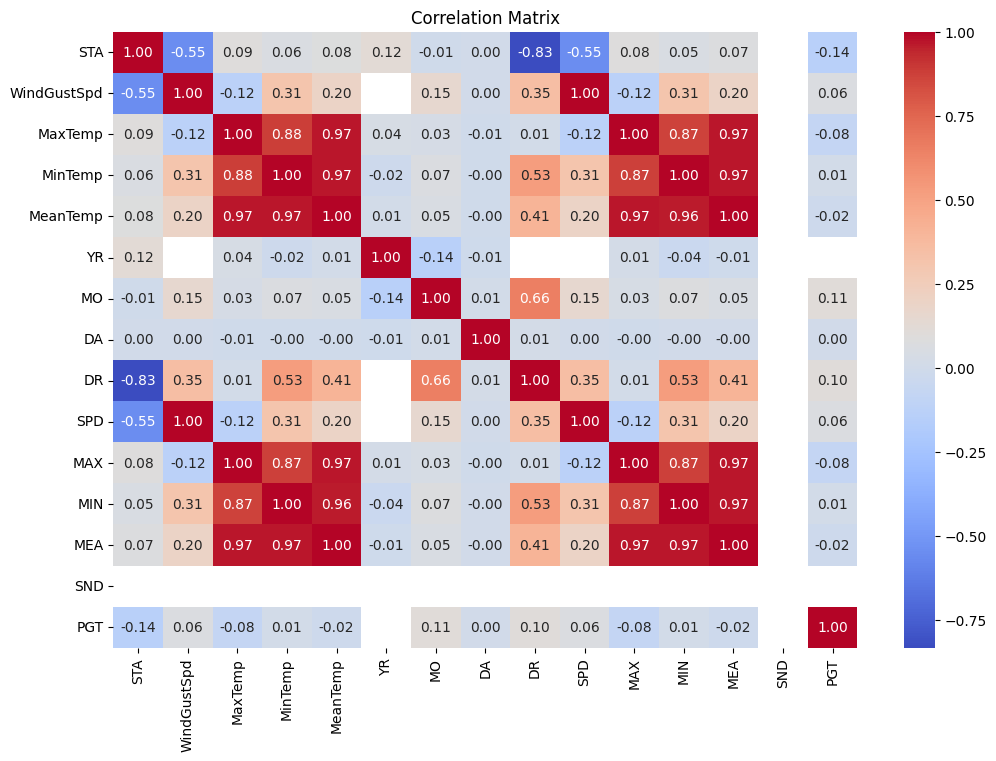

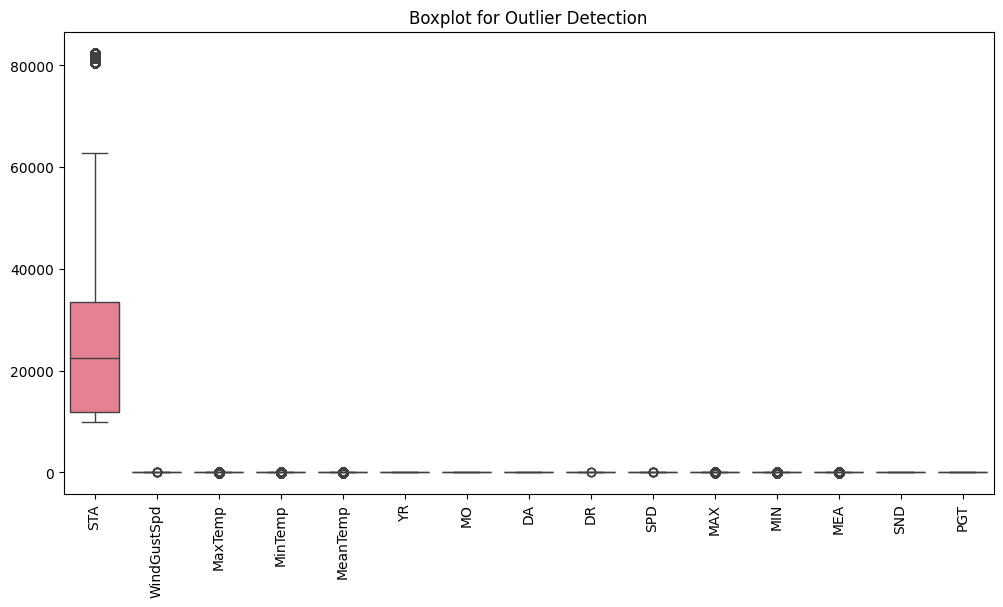

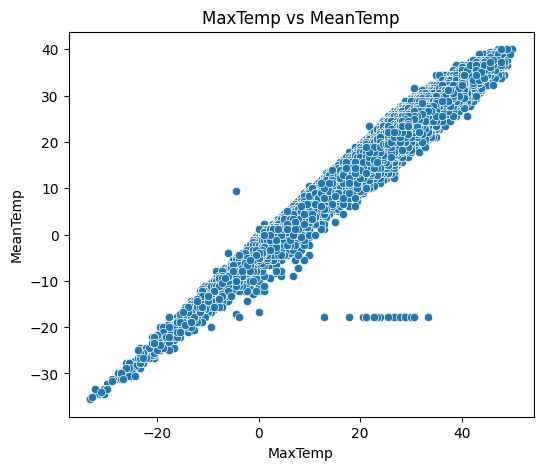

MAE: 0.02178221537107015
MSE: 0.13161588170656335
RMSE: 0.36278903195461043
R2 Score: 0.9980625385686023


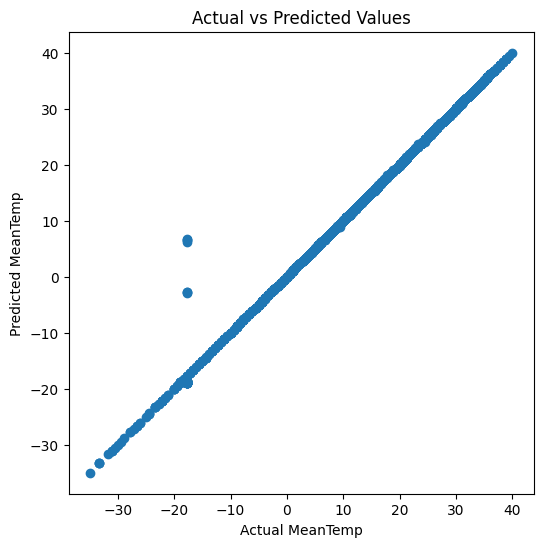

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

file_path = "/content/Summary of Weather.csv"
df = pd.read_csv(file_path, low_memory=False)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')

print("Numeric columns:\n", numeric_df.columns)
print(numeric_df.describe())

# Histogram
numeric_df.hist(figsize=(15,10), bins=20)
plt.suptitle("Histogram of Numeric Features")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,5))
sns.scatterplot(x="MaxTemp", y="MeanTemp", data=numeric_df)
plt.title("MaxTemp vs MeanTemp")
plt.show()

# Target Variable
target = "MeanTemp"

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

X = X.fillna(X.mean())
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MeanTemp")
plt.ylabel("Predicted MeanTemp")
plt.title("Actual vs Predicted Values")
plt.show()